## EDA — Entendimiento y calidad

Se lee la data contrataciones públicas (OCDS, 2023-2025) desde `data/raw/`. Se aplana y se guarda en `data/staging/`

### Imports

In [1]:
import os, socket
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import ArrayType, StructType

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
data = proyecto / "data" / "raw"
staging_dir = proyecto / "data" / "staging"
anios = [2023, 2024, 2025]

def mostrar_fig(nombre):
    plt.tight_layout(); plt.show()

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("entendimiento")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---

### 1. Entendimiento del problema

El dataset son los procesos de contratación pública del Perú 2023-2025. Un archivo por mes y año, donde cada proceso es un "release" con datos del comprador (`buyer`), el proceso de licitación (`tender`), y las adjudicaciones (`awards`)

### 2. Importancia y enfoque

Permite responder preguntas de riesgo en compras públicas, que guían las técnicas que se usarán. Todo lo que se realice rondará alrededor de esto.

#### P1 - Competencia

¿Qué combinaciones de método, monto, rubro y región se asocian a procesos con **un solo postor**?

#### P2 - Fraccionamiento / Procesos repetidos

¿Hay procesos **casi idénticos** de una misma entidad, en fechas cercanas y con montos bajos, que sugieran dividir una compra para evadir un método más exigente?

#### P3 - Precios de referencia

Para procesos de **objeto parecido** (misma `categoria`, descripción similar — ej. "laptops para oficina" en dos regiones), ¿cuánto varía el monto contratado? Una diferencia grande entre compras casi idénticas es indicio de sobreprecio.


### 3. Carga de datos

#### a. Auxiliares

In [5]:
def col(p, tipo="string"):
    return F.col(p).cast(tipo) if existe(p) else F.lit(None).cast(tipo)

def fecha(c):
    return F.to_timestamp(F.substring(c.cast("string"), 1, 19), "yyyy-MM-dd'T'HH:mm:ss")

def rutas(schema, pre=""):
    out = []
    for f in schema.fields:
        out.append(pre + f.name)
        t = f.dataType.elementType if isinstance(f.dataType, ArrayType) else f.dataType
        if isinstance(t, StructType):
            out += rutas(t, pre + f.name + ".")
    return out

#### b. Lectura de archivos

In [6]:
def listar_archivos(data, anios):
    archivos = []
    for a in anios:
        archivos += sorted((data / str(a)).glob("*.json"), key=lambda p: (len(p.stem), p.stem))
    return archivos

def resumen_archivos(archivos):
    return sum(a.stat().st_size for a in archivos) / 1024**2

def leer_json(spark, archivos):
    return spark.read.option("multiLine", "true").option("mode", "PERMISSIVE").json([str(a) for a in archivos])

def extraer_releases(raw):
    # El envoltorio OCDS puede venir de 3 formas: se detecta en vez de asumirlo.
    top = {c.lower() for c in raw.columns}
    if "releases" in top:
        return raw.select(F.explode("releases").alias("r")).select("r.*")
    elif "records" in top:
        rec = raw.select(F.explode("records").alias("x"))
        return (rec.select("x.compiledRelease.*") if "compiledRelease" in rec.select("x.*").columns
                else rec.select(F.explode("x.releases").alias("r")).select("r.*"))
    return raw


# --- flujo principal ---
archivos = listar_archivos(data, anios)
MB_JSON = resumen_archivos(archivos)
raw = leer_json(spark, archivos)
rel = extraer_releases(raw)
existe = lambda p: p.lower() in {r.lower() for r in rutas(rel.schema)}
print(f"{len(archivos)} archivos | {MB_JSON:,.1f} MB")

36 archivos | 3,859.9 MB


#### c. Vista plana

In [7]:
base = rel.select(
    col("ocid").alias("ocid"),
    F.coalesce(fecha(col("tender.tenderPeriod.startDate")),
               fecha(F.element_at(col("awards.date", "array<string>"), 1)),
               fecha(col("date"))).alias("fecha"),
    F.coalesce(col("tender.procuringEntity.name"), col("buyer.name")).alias("entidad"),
    F.input_file_name().alias("_archivo"),
    (F.expr("element_at(filter(transform(parties, p -> CASE WHEN array_contains(p.roles,'buyer') "
            "THEN p.address.region END), x -> x IS NOT NULL), 1)")
     if existe("parties.address.region") else F.lit(None).cast("string")).alias("region"),
    col("tender.title").alias("codigo_proceso"),
    col("tender.description").alias("descripcion"),
    F.concat_ws(" ", col("tender.items.description", "array<string>")).alias("items_desc"),
    col("tender.status").alias("estado"),
    col("tender.procurementMethod").alias("metodo"),
    col("tender.procurementMethodDetails").alias("metodo_detalle"),
    col("tender.mainProcurementCategory").alias("categoria"),
    col("tender.value.amount", "double").alias("monto_referencial"),
    col("tender.value.currency").alias("moneda"),
    col("tender.numberOfTenderers", "int").alias("n_postores"),
    (F.expr("aggregate(filter(awards.value.amount, x -> x IS NOT NULL), CAST(NULL AS DOUBLE), "
            "(acc, x) -> coalesce(acc, 0D) + x)")
     if existe("awards.value.amount") else F.lit(None).cast("double")).alias("monto_adjudicado"),
    (F.expr("element_at(filter(transform(awards, a -> element_at(a.suppliers.name, 1)), x -> x IS NOT NULL), 1)")
     if existe("awards.suppliers.name") else F.lit(None).cast("string")).alias("proveedor"),
    (F.expr("array_distinct(filter(flatten(transform(coalesce(tender.items, array()), "
            "i -> transform(filter(coalesce(i.additionalClassifications, array()), "
            "c -> upper(c.scheme) = 'UNSPSC'), c -> c.id))), x -> x IS NOT NULL))")
     if existe("tender.items.additionalClassifications.id") else F.array().cast("array<string>")).alias("unspsc"),
)

base = (base
        .withColumn("anio_carpeta", F.regexp_extract("_archivo", r"/(\d{4})/[^/]+\.json$", 1).cast("int"))
        .withColumn("anio", F.coalesce(F.year("fecha"), F.col("anio_carpeta")))
        .drop("_archivo", "anio_carpeta"))

base.write.mode("overwrite").parquet(str(staging_dir))
base = spark.read.parquet(str(staging_dir)).cache()
N = base.count()
print(f"Staging listo: {N:,} filas x {len(base.columns)} columnas")

Staging listo: 236,229 filas x 18 columnas


#### d. Volumen y esquema

In [8]:
n_ocid = base.select("ocid").distinct().count()
mb_pq = sum(f.stat().st_size for f in staging_dir.rglob("*.parquet")) / 1024**2

print(f"Procesos (filas): {N:,} | ocid únicos: {n_ocid:,} | repetidos: {N - n_ocid:,}")
print(f"Tamaño: JSON {MB_JSON:,.0f} MB  ->  Parquet {mb_pq:,.1f} MB")

base.groupBy("anio").count().orderBy("anio").show()
base.printSchema()

Procesos (filas): 236,229 | ocid únicos: 236,229 | repetidos: 0
Tamaño: JSON 3,860 MB  ->  Parquet 53.0 MB
+----+-----+
|anio|count|
+----+-----+
|2023|76390|
|2024|80263|
|2025|79301|
|2026|  275|
+----+-----+

root
 |-- ocid: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- codigo_proceso: string (nullable = true)
 |-- descripcion: string (nullable = true)
 |-- items_desc: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- metodo: string (nullable = true)
 |-- metodo_detalle: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- monto_referencial: double (nullable = true)
 |-- moneda: string (nullable = true)
 |-- n_postores: integer (nullable = true)
 |-- monto_adjudicado: double (nullable = true)
 |-- proveedor: string (nullable = true)
 |-- unspsc: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- anio: integer (nullable = t

- El volumen en filas es manejable, pero hay un costo real está en parsear los archivos anidados. Por eso se pasa a Parquet y se trabaja sobre estos, que son mucho más livianos. Se guardan en `data/staging`


### 4. Descripción de columnas

| Columna | Origen OCDS | Significado |
|---|---|---|
| `ocid` | `ocid` | Identificador único del proceso de contratación |
| `fecha` | `tender.tenderPeriod.startDate` → `awards[0].date` → `date` | Fecha de referencia del proceso (inicio de convocatoria, o adjudicación si no hay convocatoria) |
| `entidad` | `tender.procuringEntity.name` / `buyer.name` | Entidad compradora (quién contrata) |
| `region` | `parties[].address.region` (rol `buyer`) | Región de la entidad compradora |
| `codigo_proceso` | `tender.title` | Título/código corto del proceso |
| `descripcion` | `tender.description` | Descripción textual de lo que se contrata |
| `items_desc` | `tender.items[].description` | Descripción de los ítems individuales del proceso |
| `estado` | `tender.status` | Estado del proceso (activo, adjudicado, etc.) |
| `metodo` / `metodo_detalle` | `tender.procurementMethod` / `...MethodDetails` | Método de contratación usado (ej. Adjudicación Simplificada) |
| `categoria` | `tender.mainProcurementCategory` | Categoría principal (bienes, servicios, obras) |
| `monto_referencial` | `tender.value.amount` | Monto estimado antes de adjudicar |
| `moneda` | `tender.value.currency` | Moneda del monto referencial |
| `n_postores` | `tender.numberOfTenderers` | Número de postores que participaron (clave para medir competencia) |
| `monto_adjudicado` | suma de `awards[].value.amount` | Monto final adjudicado |
| `proveedor` | `awards[0].suppliers[0].name` | Proveedor ganador |
| `unspsc` | `tender.items[].additionalClassifications` (esquema UNSPSC) | Códigos de clasificación del objeto de compra |
| `anio` | `year(fecha)` o carpeta `data/raw/<anio>/` | Año del proceso, usado para particionar en el KDD |

### 5. Calidad de datos

#### a. Nulos

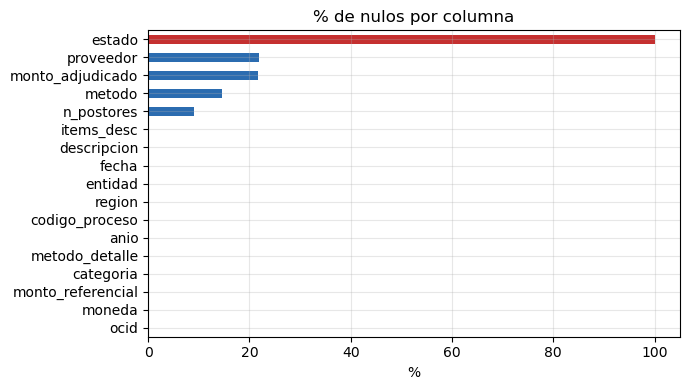

In [9]:
cols_simples = [c for c, t in base.dtypes if not t.startswith("array")]
nulos = (base.select([(100 * F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), 1)) / N)
            .alias(c) for c in cols_simples]).toPandas().T[0].sort_values())

nulos.plot.barh(figsize=(7, 4), color=["#c53030" if v > 50 else "#2b6cb0" for v in nulos])
plt.title("% de nulos por columna"); plt.xlabel("%")
mostrar_fig("nulos")

- `estado` nunca viene informado (100% nulo)

- `proveedor` y `monto_adjudicado` faltan en ~22% de los procesos (procesos aún no adjudicados o desiertos)

- `metodo` falta en ~15% (se reemplaza por `metodo_detalle`) y `n_postores` en ~9%

- El resto de columnas está prácticamente completo (<0.1% nulo)

#### b. Duplicados

In [10]:
dup_ocids = base.groupBy("ocid").count().where("count > 1")
n_dup = dup_ocids.count()
print(f"ocid con más de un registro: {n_dup} de {n_ocid:,} ocid únicos")

if n_dup > 0:
    ejemplo = dup_ocids.limit(1).collect()[0]["ocid"]
    base.where(F.col("ocid") == ejemplo).select("ocid", "fecha", "entidad", "anio").show(truncate=False)

ocid con más de un registro: 0 de 236,229 ocid únicos


- No hay `ocid` repetidos en este corte (236,229 filas = 236,229 `ocid` únicos)

#### c. Casi-duplicados

In [11]:
casi_dup = (base.groupBy("entidad", "fecha", "monto_referencial", "descripcion")
            .agg(F.countDistinct("ocid").alias("ocids"), F.collect_list("ocid").alias("lista_ocid"))
            .where("ocids > 1"))

n_grupos = casi_dup.count()
n_filas = casi_dup.select(F.explode("lista_ocid")).count()
print(f"Grupos con mismo contenido pero ocid distinto: {n_grupos} ({n_filas} filas involucradas)")
casi_dup.select("entidad", "fecha", "monto_referencial", "lista_ocid").show(5, truncate=50)

Grupos con mismo contenido pero ocid distinto: 9276 (20711 filas involucradas)
+-----------------------------------------+-------------------+-----------------+--------------------------------------------------+
|                                  entidad|              fecha|monto_referencial|                                        lista_ocid|
+-----------------------------------------+-------------------+-----------------+--------------------------------------------------+
|              ACADEMIA DE LA MAGISTRATURA|2025-04-21 00:00:00|        808498.86|[ocds-dgv273-seacev3-1136780, ocds-dgv273-seace...|
|AGENCIA DE COMPRAS DE LAS FUERZAS ARMADAS|2023-06-12 00:00:00|         600000.0|[ocds-dgv273-seacev3-2023-10248-150, ocds-dgv27...|
|AGENCIA DE COMPRAS DE LAS FUERZAS ARMADAS|2023-07-21 00:00:00|        442934.75|[ocds-dgv273-seacev3-2023-10247-7, ocds-dgv273-...|
|AGENCIA DE COMPRAS DE LAS FUERZAS ARMADAS|2023-12-01 00:00:00|    1.739647973E7|[ocds-dgv273-seacev3-2023-10249-396, ocds-

- 9,276 grupos (20,711 filas, ~8.8% del dataset) comparten entidad, fecha, monto y descripción exactos, pero cada uno bajo un `ocid`

- Pueden ser republicaciones del mismo proceso (error) o procesos legítimamente idénticos en papeleo pero distintos en la práctica 

#### d. Inconsistencias

In [12]:
base.select(F.sum((F.col("monto_referencial") <= 0).cast("int")).alias("monto_<=0"),
            F.sum((F.col("moneda") != "PEN").cast("int")).alias("moneda_no_PEN")).show()

+---------+-------------+
|monto_<=0|moneda_no_PEN|
+---------+-------------+
|    16203|         4797|
+---------+-------------+



- 16,203 procesos (~6.9%) tienen `monto_referencial` ≤ 0 — valor imposible, probablemente "no informado", codificado como 0

- 4,797 procesos (~2.0%) están en una moneda distinta de PEN, no comparables directamente en soles

#### Acciones previstas

| Error | Acción prevista |
|---|---|
| `ocid` repetidos | quedarse con el registro más reciente por `ocid` |
| Casi-duplicados | no se eliminan automáticamente |
| `estado`/`metodo` casi siempre nulos | se descartan como columnas (no aportan) |
| `monto_referencial` ≤ 0 | se ponen en nulo (valor imposible), el proceso se conserva |
| `moneda` distinta de PEN | se filtran esos procesos (no son comparables en soles) |
| fechas fuera de 2023-2025 | se descartan (fuera del alcance del proyecto) |

---

### 6. Cierre de sesión

In [13]:
spark.stop()